In [133]:
import pandas as pd

In [134]:
df = pd.read_csv('/Users/melanyalegre/Documents/International Business/4th year/Data Analytics/Data Science/DS_assignment_data - Copy (1).csv')
df.head()

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,DISBURSAL_DATE,MOBILENO_AVL_FLAG,...,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
0,420825,50578,58400,89.55,67,1441,01/01/1984,Salaried,03/08/2018,1,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,537409,47145,65550,73.23,67,1502,31/07/1985,Self employed,26/09/2018,1,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
2,417566,53278,61360,89.63,67,1497,24/08/1985,Self employed,01/08/2018,1,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
3,624493,57513,66113,88.48,67,1501,30/12/1993,Self employed,26/10/2018,1,...,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
4,539055,52378,60300,88.39,67,1495,09/12/1977,Self employed,26/09/2018,1,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1


In [135]:
df = df.drop(columns=['UNIQUEID', 'BRANCH_ID', 'CURRENT_PINCODE_ID','DATE_OF_BIRTH','DISBURSAL_DATE','PERFORM_CNS_SCORE_DESCRIPTION'])

In [136]:
df.dtypes


DISBURSED_AMOUNT                         int64
ASSET_COST                               int64
LTV                                    float64
EMPLOYMENT_TYPE                         object
MOBILENO_AVL_FLAG                        int64
AADHAR_FLAG                              int64
PAN_FLAG                                 int64
VOTERID_FLAG                             int64
DRIVING_FLAG                             int64
PASSPORT_FLAG                            int64
PERFORM_CNS_SCORE                        int64
PRI_NO_OF_ACCTS                          int64
PRI_ACTIVE_ACCTS                         int64
PRI_OVERDUE_ACCTS                        int64
PRI_CURRENT_BALANCE                      int64
PRI_SANCTIONED_AMOUNT                    int64
PRI_DISBURSED_AMOUNT                     int64
SEC_NO_OF_ACCTS                          int64
SEC_ACTIVE_ACCTS                         int64
SEC_OVERDUE_ACCTS                        int64
SEC_CURRENT_BALANCE                      int64
SEC_SANCTIONE

In [137]:
df.isnull().sum()

DISBURSED_AMOUNT                         0
ASSET_COST                               0
LTV                                      0
EMPLOYMENT_TYPE                        144
MOBILENO_AVL_FLAG                        0
AADHAR_FLAG                              0
PAN_FLAG                                 0
VOTERID_FLAG                             0
DRIVING_FLAG                             0
PASSPORT_FLAG                            0
PERFORM_CNS_SCORE                        0
PRI_NO_OF_ACCTS                          0
PRI_ACTIVE_ACCTS                         0
PRI_OVERDUE_ACCTS                        0
PRI_CURRENT_BALANCE                      0
PRI_SANCTIONED_AMOUNT                    0
PRI_DISBURSED_AMOUNT                     0
SEC_NO_OF_ACCTS                          0
SEC_ACTIVE_ACCTS                         0
SEC_OVERDUE_ACCTS                        0
SEC_CURRENT_BALANCE                      0
SEC_SANCTIONED_AMOUNT                    0
SEC_DISBURSED_AMOUNT                     0
PRIMARY_INS

In [138]:
df['EMPLOYMENT_TYPE'] = df['EMPLOYMENT_TYPE'].fillna('Unknown')

In [139]:
df = pd.get_dummies(df, columns=['EMPLOYMENT_TYPE'], drop_first=True)

AI CODE

In [140]:
def convert_to_months(age_string):
    years = int(age_string.split('yrs')[0])
    months = int(age_string.split(' ')[1].replace('mon',''))
    return years*12 + months

In [141]:
df["AVERAGE_ACCT_AGE"] = df["AVERAGE_ACCT_AGE"].apply(convert_to_months)
df["CREDIT_HISTORY_LENGTH"] = df["CREDIT_HISTORY_LENGTH"].apply(convert_to_months)

In [142]:
df.dtypes


DISBURSED_AMOUNT                         int64
ASSET_COST                               int64
LTV                                    float64
MOBILENO_AVL_FLAG                        int64
AADHAR_FLAG                              int64
PAN_FLAG                                 int64
VOTERID_FLAG                             int64
DRIVING_FLAG                             int64
PASSPORT_FLAG                            int64
PERFORM_CNS_SCORE                        int64
PRI_NO_OF_ACCTS                          int64
PRI_ACTIVE_ACCTS                         int64
PRI_OVERDUE_ACCTS                        int64
PRI_CURRENT_BALANCE                      int64
PRI_SANCTIONED_AMOUNT                    int64
PRI_DISBURSED_AMOUNT                     int64
SEC_NO_OF_ACCTS                          int64
SEC_ACTIVE_ACCTS                         int64
SEC_OVERDUE_ACCTS                        int64
SEC_CURRENT_BALANCE                      int64
SEC_SANCTIONED_AMOUNT                    int64
SEC_DISBURSED

In [143]:
df.describe()

,DISBURSED_AMOUNT,ASSET_COST,LTV,MOBILENO_AVL_FLAG,AADHAR_FLAG,PAN_FLAG,VOTERID_FLAG,DRIVING_FLAG,PASSPORT_FLAG,PERFORM_CNS_SCORE,...,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
count,5000.000000,5000.000000,5000.000000,5000.0,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.00000,5000.000000
mean,52618.059800,75361.666000,72.859102,1.0,0.705400,0.097800,0.268400,0.030800,0.001600,261.070000,...,8.255959e+03,8.184883e+03,6.752016e+03,259.952800,0.314800,0.08860,8.602200,14.772000,0.19120,0.224400
std,11356.022842,16511.840509,11.417345,0.0,0.455908,0.297074,0.443171,0.172793,0.039972,332.599411,...,1.378150e+05,1.376109e+05,5.275792e+04,7914.561715,0.857816,0.35941,15.310272,26.939183,0.76887,0.417228
min,13990.000000,39605.000000,17.050000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000
25%,46176.750000,65831.000000,66.837500,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000
50%,52603.000000,70764.000000,74.850000,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000
75%,58585.000000,78800.250000,80.610000,1.0,1.000000,0.000000,1.000000,0.000000,0.000000,651.000000,...,0.000000e+00,0.000000e+00,1.582000e+03,0.000000,0.000000,0.00000,12.000000,21.000000,0.00000,0.000000
max,151143.000000,225100.000000,94.990000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,879.000000,...,6.425000e+06,6.425000e+06,1.948754e+06,504063.000000,14.000000,5.00000,154.000000,296.000000,18.00000,1.000000


In [144]:
corr = df.corr()

corr["DISBURSED_AMOUNT"].sort_values(ascending=False)

DISBURSED_AMOUNT                       1.000000
ASSET_COST                             0.696747
LTV                                    0.438774
LOAN_DEFAULT                           0.105253
EMPLOYMENT_TYPE_Unknown                0.065989
VOTERID_FLAG                           0.056148
DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS    0.052429
PRI_NO_OF_ACCTS                        0.036486
NEW_ACCTS_IN_LAST_SIX_MONTHS           0.035209
PRI_OVERDUE_ACCTS                      0.029049
PRI_ACTIVE_ACCTS                       0.026774
PRI_CURRENT_BALANCE                    0.022317
NO_OF_INQUIRIES                        0.020236
PRI_DISBURSED_AMOUNT                   0.019303
PRI_SANCTIONED_AMOUNT                  0.019143
SEC_INSTAL_AMT                         0.011213
SEC_NO_OF_ACCTS                        0.010816
DRIVING_FLAG                           0.009953
SEC_ACTIVE_ACCTS                       0.007609
SEC_DISBURSED_AMOUNT                   0.002329
SEC_SANCTIONED_AMOUNT                  0

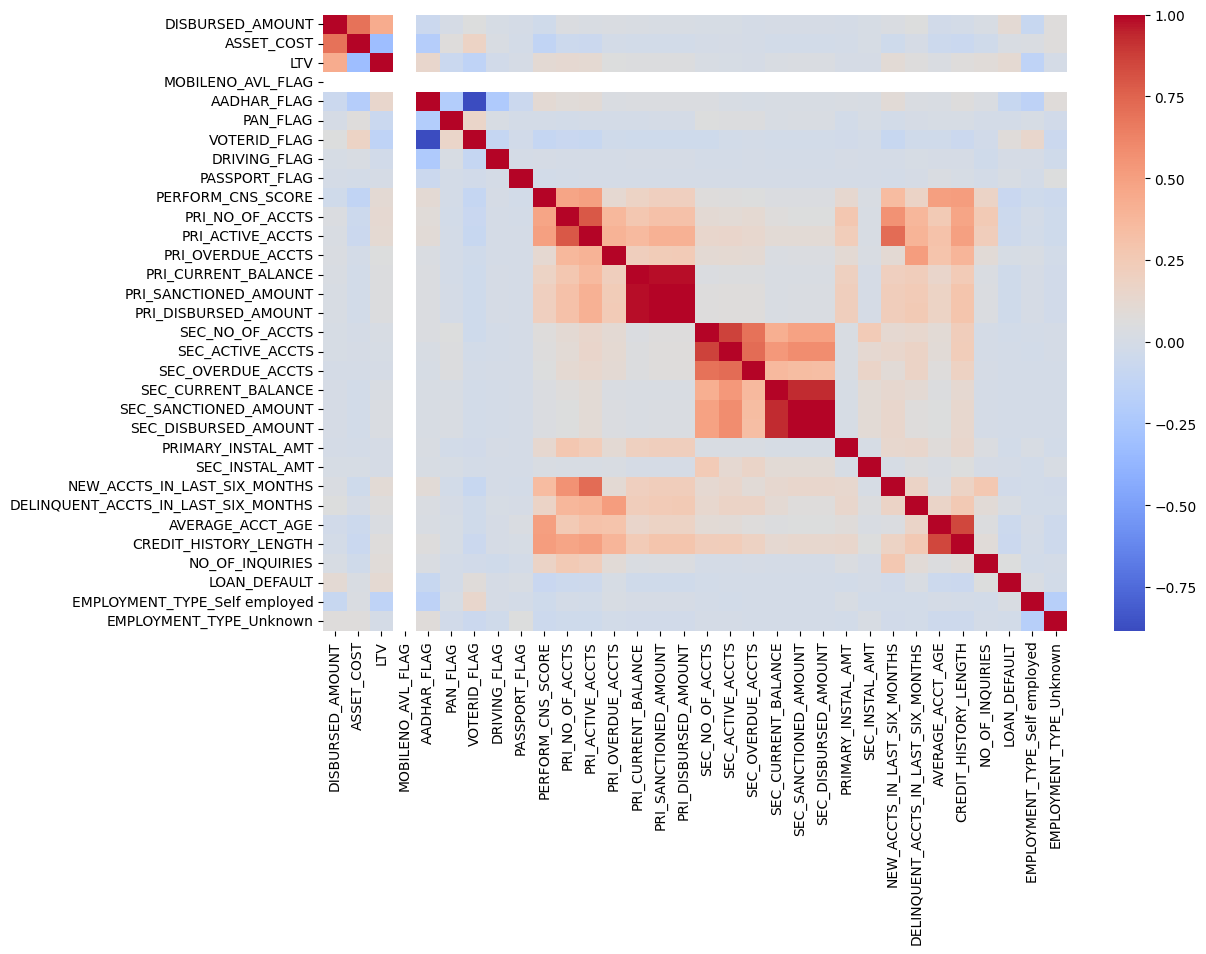

In [148]:
import seaborn as sn
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sn.heatmap(df.corr(), cmap="coolwarm")
plt.show()

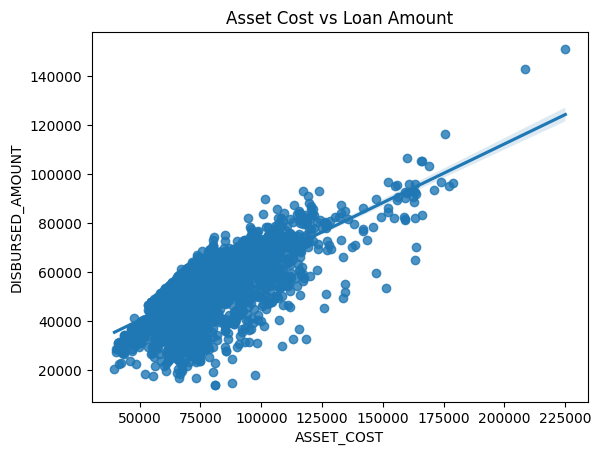

In [149]:
sns.regplot(x="ASSET_COST", y="DISBURSED_AMOUNT", data=df)
plt.title("Asset Cost vs Loan Amount")
plt.show()

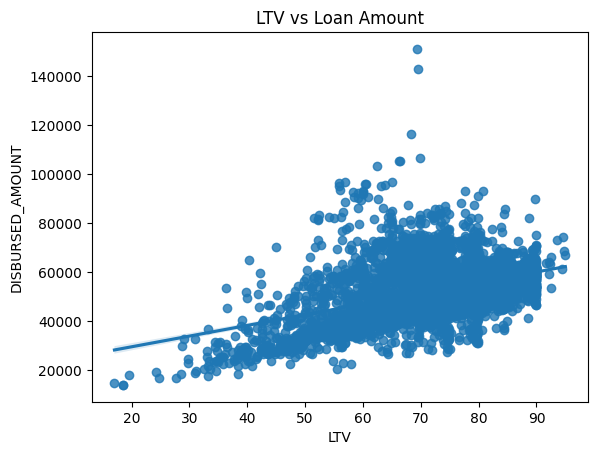

In [150]:
sns.regplot(x="LTV", y="DISBURSED_AMOUNT", data=df)
plt.title("LTV vs Loan Amount")
plt.show()